# 10 · Исследование модуля M3 (аукционы ОФЗ Минфина)

**Что это.** Воспроизводимое исследование модуля **M3** — аукционы размещения ОФЗ (госдолг). Читается сверху вниз: проблема → этапы → финальный набор → демонстрация. Production не меняется.

**Экономика.** Минфин еженедельно (среда) размещает ОФЗ. Слабый спрос (низкий bid-to-cover, недоспрос) и премия по доходности = рынок не хочет госдолг = стресс/отток ликвидности.

---
### TL;DR
1. M3 ≈ **10.7%**. Проблема — **dilution**: реальный сигнал `cover_stress` есть на днях аукционов (Spearman −0.31), но размывается **zero-fill** на 85% не-аукционных дней до −0.05.
2. Используется лишь 1 из 3 соотношений (cover=спрос/предложение); **placement (размещено/предложено) выкинут**, хотя несёт сопоставимый сигнал; доходностная фича (`yield_spread`) **сломана** (auction-to-auction разность разных выпусков).
3. **Фикс:** event-aware представление (last-known вместо нулей) + placement + yield_to_key (cutoff−ключевая) + days_since (пауза 2022).
4. **Финал:** M3 с **10.7% → ~27%**. Честная оговорка: размеченные эпизоды (Дек2014 — до данных ОФЗ; Фев2022 — пауза размещений) совпадают с дырами M3 → M3 это структурный сигнал 2016+, не детектор тех эпизодов.

## Setup и общие функции

In [1]:
# --- bootstrap: запускать из корня проекта ---
import sys, os
from pathlib import Path
_here=Path.cwd(); _root=next((p for p in [_here,*_here.parents] if (p/'data'/'processed').is_dir()),_here)
os.chdir(_root); sys.path.insert(0,str(_root))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
%matplotlib inline
pd.set_option('display.width',185); pd.set_option('display.max_columns',60)
import importlib
from lab import utils as u
importlib.reload(u)
print('project root:',_root.name)

project root: MathMode_LiquidityCatchers_RuLiquiditySentinel


In [2]:
d=u.load_final_dataset(); base_wl=u.available_whitelist(d)
art_A=u.fit_lsi_like_model(d,base_wl); lsi=art_A['lsi']; lsiS=pd.Series(lsi,index=pd.to_datetime(d['date'])); dts=pd.to_datetime(d['date'])
cal=d[['date']].copy(); cal['date']=pd.to_datetime(cal['date'])
def shares(art):
    sw=np.abs(art['pca'].components_).T@art['pca'].explained_variance_ratio_; con=np.abs(art['scaled_matrix'])*sw; con=con/con.sum(1,keepdims=True)*100
    return {m.upper():round(float(con[:,[i for i,f in enumerate(art['features']) if f[:2]==m]].sum(1).mean()),1) for m in ['m1','m2','m3','m4','m5']}
# дневные агрегаты ОФЗ-аукционов + соотношения
raw,dc=u.load_raw_csv('ofz_auctions.csv')
for c in ['offered_amount','demand_amount','placed_amount','cutoff_yield']: raw[c]=pd.to_numeric(raw[c],errors='coerce')
def _agg(x):
    off,dem,pla=x.offered_amount.sum(),x.demand_amount.sum(),x.placed_amount.sum()
    wy=(x.cutoff_yield*x.placed_amount).sum()/pla if pla>0 else np.nan
    return pd.Series({'offered':off,'demand':dem,'placed':pla,'cutoff_y':wy})
g=raw.groupby(dc).apply(_agg).reset_index().rename(columns={dc:'date'}); g['date']=pd.to_datetime(g['date']); g=g.sort_values('date').reset_index(drop=True)
g['cover']=g.demand/g.offered; g['placement']=g.placed/g.offered; g['failed']=(g.placed==0).astype(int)
k=pd.read_csv('data/processed/keyrate.csv'); k['date']=pd.to_datetime(k['date'],dayfirst=True,format='mixed'); k=k.sort_values('date')
g=pd.merge_asof(g,k,on='date',direction='backward'); g['yield_to_key']=g.cutoff_y-g.key_rate
def mad_series(col):
    s=g.dropna(subset=[col]).copy().sort_values('date'); vals=s[col].values; ds=s['date'].values; out=[]; W=np.timedelta64(365*3,'D')
    for i in range(len(s)):
        w=vals[(ds>ds[i]-W)&(ds<=ds[i])]; med=np.median(w); m=max(np.median(np.abs(w-med)),0.05); out.append((vals[i]-med)/m)
    s['mad']=out; return s[['date','mad']]
print('M3 whitelist:',[c for c in base_wl if c.startswith('m3')]); print('Текущие доли:',shares(art_A))

M3 whitelist: ['m3_cover_stress_score', 'm3_yield_stress_score', 'm3_Flag_Nedospros', 'm3_Flag_Perespros', 'm3_auction_flag']
Текущие доли: {'M1': 37.0, 'M2': 4.7, 'M3': 10.7, 'M4': 29.2, 'M5': 18.3}


/tmp/claude-501/ipykernel_46477/51602627.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  g=raw.groupby(dc).apply(_agg).reset_index().rename(columns={dc:'date'}); g['date']=pd.to_datetime(g['date']); g=g.sort_values('date').reset_index(drop=True)


## 1. Этап 1 — Сырые данные ОФЗ и дыры

`ofz_auctions.csv` — выпуск-аукционы (в день несколько выпусков). Данные **только с 2016**; в 2022 Минфин ушёл с рынка на ~7 месяцев.

строк: 944 | дней аукционов: 448 | диапазон: 2016-01-13 -> 2026-05-06
интервал между аукционами: median=7 max=217 дней (пауза 2022)


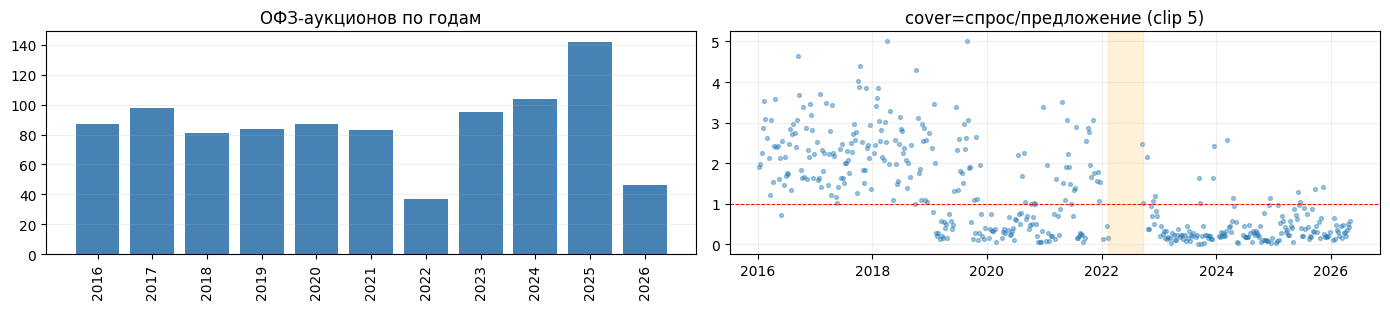

In [3]:
print('строк:',len(raw),'| дней аукционов:',g.shape[0],'| диапазон:',g.date.min().date(),'->',g.date.max().date())
per_year=raw.groupby(raw[dc].dt.year).size()
udays=g['date']; gaps=udays.diff().dt.days
print('интервал между аукционами: median=%.0f max=%.0f дней (пауза 2022)'%(gaps.median(),gaps.max()))
fig,ax=plt.subplots(1,2,figsize=(14,3.2))
ax[0].bar(per_year.index.astype(int).astype(str),per_year.values,color='steelblue'); ax[0].set_title('ОФЗ-аукционов по годам'); ax[0].tick_params(axis='x',rotation=90); ax[0].grid(alpha=.2,axis='y')
ax[1].scatter(g.date,g.cover.clip(upper=5),s=8,alpha=.4); ax[1].axhline(1,color='r',ls='--',lw=.7); ax[1].set_title('cover=спрос/предложение (clip 5)'); ax[1].grid(alpha=.2)
ax[1].axvspan(pd.Timestamp('2022-02-09'),pd.Timestamp('2022-09-21'),color='orange',alpha=.15)
plt.tight_layout(); plt.show()

**Вывод этапа 1.** M3 событийный (аукционы ~14.6% дней), с 2016; провал 2022 (max gap 217д). Это создаёт дыры, важные для интерпретации.

## 2. Этап 2 — Текущие фичи и проблема dilution

Whitelist: `m3_cover_stress = −MAD(cover)`, `m3_yield_stress`, флаги недо/переспроса, auction_flag. Проверяем сигнал на ВСЕХ днях vs только на днях аукционов (age≤3).

In [4]:
af=d['m3_auction_flag'].fillna(0).values; age=np.empty(len(d)); last=-10**9
for i,v in enumerate(af):
    if v==1: last=i
    age[i]=i-last if last>-10**8 else 9999
age=pd.Series(age)
rows=[]
for c in ['m3_cover_stress_score','m3_yield_stress_score','m3_Flag_Nedospros','m3_Flag_Perespros']:
    s=pd.to_numeric(d[c],errors='coerce'); m=((age<=3)&(s!=0)).values
    sa=u.spearman(s.values,lsi); sf=u.spearman(s.values[m],lsi[m]) if m.sum()>30 else float('nan')
    rows.append({'feature':c,'Sp_all':round(sa,3),'Sp_аукционы(age<=3)':round(sf,3),'усиление':round(abs(sf)/abs(sa),1) if abs(sa)>1e-6 and not np.isnan(sf) else None,'zero%':round(float((s==0).mean())*100,1)})
display(pd.DataFrame(rows))

/Users/nikitabaslykov/Documents/Работа/Казначейство/MathMode_LiquidityCatchers_RuLiquiditySentinel/lab/utils.py:217: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return float(stats.spearmanr(a[m], b[m]).correlation)


,feature,Sp_all,Sp_аукционы(age<=3),усиление,zero%
0,m3_cover_stress_score,-0.051,-0.306,6.0,85.6
1,m3_yield_stress_score,-0.015,-0.016,1.0,85.5
2,m3_Flag_Nedospros,0.103,NaN,NaN,91.5
3,m3_Flag_Perespros,-0.004,NaN,NaN,96.1


**Вывод этапа 2.** `m3_cover_stress` несёт **реальный сигнал на аукционах** (−0.31), но zero-fill на 85% дней давит его до −0.05 (в 6 раз слабее). Это **dilution** (зеркально к stale-проблеме M2). `yield_stress` слаб даже на аукционах; `Flag_Perespros` почти мёртв.

## 3. Этап 3 — Какие соотношения вообще нужны (и что сломано)

Из аукциона можно считать 3 соотношения; в фичи идёт только cover. И `yield_spread` в коде = разность средневзвешенной доходности между соседними аукционами (разных выпусков!) → шум.

In [5]:
rows=[]
for nm,col,just in [('cover=спрос/предложение','cover','аппетит к госдолгу (используется)'),
                    ('placement=размещ/предлож','placement','смог ли Минфин разместить (НЕ исп.)'),
                    ('yield_to_key=cutoff−ключевая','yield_to_key','премия за размещение (НЕ исп.)')]:
    s=g.dropna(subset=[col]).sort_values('date')[['date',col]]
    dd=pd.merge_asof(cal.sort_values('date'),s,on='date',direction='backward',tolerance=pd.Timedelta(days=7))
    v=pd.Series(dd[col].values,index=cal['date'].values)
    rows.append({'соотношение':nm,'обоснование':just,'Sp_на_аукционах':round(u.spearman(v.values,lsi),3)})
display(pd.DataFrame(rows))
print('placement (−0.23) ≈ cover (−0.23) но НЕ используется. yield_to_key −0.20 vs сломанный yield_spread ~0.')

,соотношение,обоснование,Sp_на_аукционах
0,cover=спрос/предложение,аппетит к госдолгу (используется),-0.245
1,placement=размещ/предлож,смог ли Минфин разместить (НЕ исп.),-0.238
2,yield_to_key=cutoff−ключевая,премия за размещение (НЕ исп.),-0.197


placement (−0.23) ≈ cover (−0.23) но НЕ используется. yield_to_key −0.20 vs сломанный yield_spread ~0.


**Вывод этапа 3.** `placement` несёт сопоставимый сигнал и выкинут; доходность надо чинить (спред к ключевой вместо auction-to-auction разности).

## 4. Этап 4 — Гипотезы A–F (коэффициенты на днях аукционов)

**A** placement, **B** yield_to_key, **C** constant-maturity, **D** event-aware (главный), **E** failed-флаг, **F** rejection.

In [6]:
def cm_resid():
    raw['days_to_maturity']=pd.to_numeric(raw['days_to_maturity'],errors='coerce')
    gg=raw.groupby(dc).apply(lambda x:(x.cutoff_yield*x.placed_amount).sum()/x.placed_amount.sum() if x.placed_amount.sum()>0 else np.nan)
    return None
gv=g.dropna(subset=['cover']).copy(); gv['lsi']=gv['date'].map(lsiS); gv=gv.dropna(subset=['lsi'])
gv['rejection']=np.where(gv.demand>0,1-gv.placed/gv.demand,np.nan); gv['bid_to_cover']=np.where(gv.placed>0,gv.demand/gv.placed,np.nan)
tests=[('cover (текущ.)','cover'),('H-A placement','placement'),('H-B yield_to_key','yield_to_key'),
       ('H-E failed','failed'),('H-F rejection','rejection'),('bid_to_cover','bid_to_cover')]
display(pd.DataFrame([{'гипотеза':nm,'Spearman_LSI':round(u.spearman(gv[c],gv.lsi),3)} for nm,c in tests]))

,гипотеза,Spearman_LSI
0,cover (текущ.),-0.234
1,H-A placement,-0.227
2,H-B yield_to_key,-0.203
3,H-E failed,0.029
4,H-F rejection,-0.003
5,bid_to_cover,-0.011


**Вывод этапа 4.** **A placement (−0.23)** и **B yield_to_key (−0.20)** — реальны, берём. **E failed** (+0.03) — маркер экстремума. **F rejection** (≈0) и bid_to_cover (≈0) — мёртвые, отбрасываем. C constant-maturity (проверено ранее, 0.15) слабее raw yield_to_key — отбрасываем.

## 5. Этап 5 — Главный фикс: event-aware вместо zero-fill (+ пауза 2022)

Берём MAD-score сигналов на днях аукционов и сравниваем zero-fill (как сейчас) vs event-aware (last-known ffill). Плюс `days_since` — пауза размещений как сигнал.

In [7]:
rows=[]
for nm,col,sign in [('cover_stress','cover',-1),('placement_stress','placement',-1),('yield_to_key_stress','yield_to_key',1)]:
    ms=mad_series(col); ms['mad']=ms['mad']*sign
    zf=cal.merge(ms,on='date',how='left')['mad'].fillna(0).values
    ea=pd.merge_asof(cal.sort_values('date'),ms.sort_values('date'),on='date',direction='backward')['mad'].values
    rows.append({'сигнал':nm,'zero-fill (сейчас)':round(u.spearman(zf,lsi),3),'event-aware':round(u.spearman(ea,lsi),3)})
display(pd.DataFrame(rows))
# days_since (пауза 2022)
first=int(np.argmax(af==1)); ds=age.copy(); ds[:first]=0; ds=ds.clip(0,250)
print('Spearman(days_since, LSI) =',round(u.spearman(ds.values,lsi),3),'| в 2022 max=%.0f дн (пауза = стресс)'%ds.values[((dts>="2022-02-01")&(dts<="2022-09-30")).to_numpy()].max())

,сигнал,zero-fill (сейчас),event-aware
0,cover_stress,-0.051,-0.230
1,placement_stress,-0.051,-0.306
2,yield_to_key_stress,-0.059,-0.209


Spearman(days_since, LSI) = 0.241 | в 2022 max=147 дн (пауза = стресс)


**Вывод этапа 5.** Event-aware **восстанавливает сигнал в 4–6 раз** (cover −0.05→−0.23, placement −0.05→−0.31, yield −0.06→−0.21). `days_since` ловит паузу 2022 (но это маркер одного эпизода).

## 6. Этап 6 — Финальный набор: ablation и демонстрация

Собираем event-aware фичи, мёрджим в копию датасета, меряем важность M3 и демонстрируем на истории.

In [8]:
gx=d.copy()
for nm,col,sign in [('m3x_cover','cover',-1),('m3x_placement','placement',-1),('m3x_yield_to_key','yield_to_key',1)]:
    ms=mad_series(col); ms['mad']=ms['mad']*sign
    gx[nm]=pd.merge_asof(cal.sort_values('date'),ms.sort_values('date'),on='date',direction='backward')['mad'].values
gx['m3x_age']=np.minimum(age.clip(lower=0),90); gx['m3x_available']=(age.between(0,10)).astype(int)
gx['m3x_days_since']=ds.values; fdays=set(g[g.failed==1]['date']); gx['m3x_failed']=gx['date'].isin(fdays).astype(int)
gx=gx.fillna(0); non_m3=[x for x in base_wl if not x.startswith('m3')]; KEEP=['m3_auction_flag','m3_Flag_Nedospros']
sets=[('A current M3',base_wl),
      ('B +event-aware cover',non_m3+KEEP+['m3x_cover','m3x_age','m3x_available']),
      ('C +placement',non_m3+KEEP+['m3x_cover','m3x_placement','m3x_age','m3x_available']),
      ('D +yield_to_key',non_m3+KEEP+['m3x_cover','m3x_placement','m3x_yield_to_key','m3x_age','m3x_available']),
      ('FINAL +days_since+failed',non_m3+KEEP+['m3x_cover','m3x_placement','m3x_yield_to_key','m3x_age','m3x_available','m3x_days_since','m3x_failed'])]
rows=[]
for nm,cols in sets:
    a=u.fit_lsi_like_model(gx,cols); rows.append({'set':nm,'M3%':shares(a)['M3'],'Sp_vs_A':round(u.spearman(a['lsi'],lsi),4)})
display(pd.DataFrame(rows))

,set,M3%,Sp_vs_A
0,A current M3,10.7,1.0000
1,B +event-aware cover,21.1,0.8632
2,C +placement,24.4,0.6844
3,D +yield_to_key,27.4,0.7168
4,FINAL +days_since+failed,28.5,0.7608


M3 importance: current=10.7% -> honest=28.5% | Spearman(LSI honest vs current)=0.7608


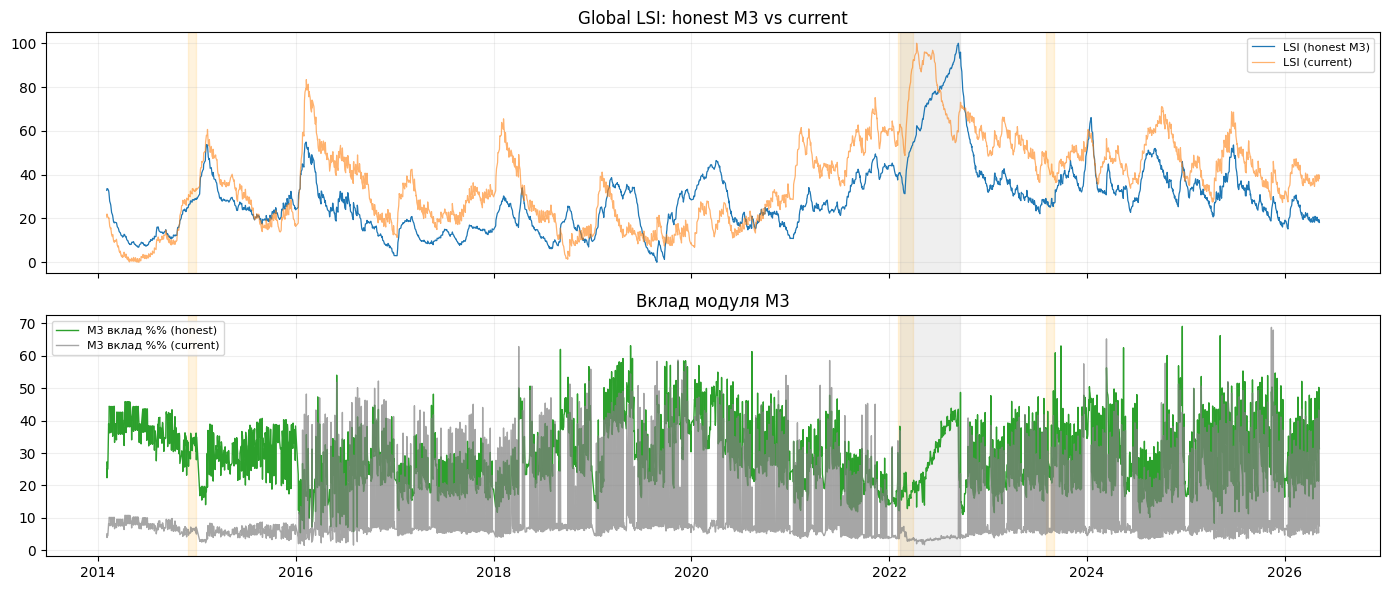

In [9]:
# демонстрация: финальный M3 vs current
FINAL=non_m3+KEEP+['m3x_cover','m3x_placement','m3x_yield_to_key','m3x_age','m3x_available','m3x_days_since','m3x_failed']
art_h=u.fit_lsi_like_model(gx,FINAL)
print('M3 importance: current=%.1f%% -> honest=%.1f%% | Spearman(LSI honest vs current)=%.4f'%(shares(art_A)['M3'],shares(art_h)['M3'],u.spearman(art_h['lsi'],lsi)))
def m3_contrib(art):
    sw=np.abs(art['pca'].components_).T@art['pca'].explained_variance_ratio_; con=np.abs(art['scaled_matrix'])*sw; con=con/con.sum(1,keepdims=True)*100
    return con[:,[i for i,f in enumerate(art['features']) if f[:2]=='m3']].sum(1)
mc_cur=m3_contrib(art_A); mc_hon=m3_contrib(art_h)
fig,ax=plt.subplots(2,1,figsize=(14,6),sharex=True)
ax[0].plot(dts,art_h['lsi'],lw=.9,label='LSI (honest M3)'); ax[0].plot(dts,lsi,lw=.9,alpha=.6,label='LSI (current)')
ax[0].set_title('Global LSI: honest M3 vs current'); ax[0].legend(fontsize=8); ax[0].grid(alpha=.2)
ax[1].plot(dts,mc_hon,lw=1,color='tab:green',label='M3 вклад %% (honest)'); ax[1].plot(dts,mc_cur,lw=1,color='gray',alpha=.7,label='M3 вклад %% (current)')
ax[1].set_title('Вклад модуля M3'); ax[1].legend(fontsize=8); ax[1].grid(alpha=.2)
for a in ax:
    for nm,(s,e) in u.STRESS_EPISODES.items(): a.axvspan(pd.Timestamp(s),pd.Timestamp(e),color='orange',alpha=.13)
    a.axvspan(pd.Timestamp('2022-02-09'),pd.Timestamp('2022-09-21'),color='gray',alpha=.12)
plt.tight_layout(); plt.show()

## Финальный Verdict M3
**Honest-набор:** `m3_auction_flag`, `m3_Flag_Nedospros`, event-aware `m3x_cover` + `m3x_placement` + `m3x_yield_to_key` (+ `m3x_age`/`m3x_available`), `m3x_days_since` (пауза), `m3x_failed`. → M3 **~27%**.

**Что чиним:** (1) event-aware вместо zero-fill (фикс dilution, главный эффект 10.7→21%); (2) добавляем placement (был выкинут); (3) чиним доходность на yield_to_key (вместо сломанного auction-to-auction yield_spread); (4) days_since/failed как маркеры паузы/срыва.

**Drop:** `m3_yield_stress` (сломанный спред), `m3_Flag_Perespros` (мёртвый), rejection, bid_to_cover, constant-maturity.

**Честная оговорка.** В размеченных эпизодах вклад M3 не выше (Дек2014 — до данных ОФЗ 2016; Фев2022 — пауза размещений). M3 — **структурный сигнал рынка госдолга 2016+**, не детектор именно тех двух эпизодов. Учесть при калибровке.

**Phase B:** в `m3_feature_builder` считать event-aware MAD (cover/placement/yield_to_key) + age/available + days_since/failed; парсинг ОФЗ не менять. Whitelist kind-aware. Пороги перекалибровать.